In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image
import time
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.version.cuda)
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

13.2
Using device: cuda
GPU: NVIDIA GeForce GTX 1660 Ti


In [98]:
INIT_LR = 0.0001
EPOCHS = 20
BS = 32
DIRECTORY = r"dataset"
CATEGORIES = ["with_mask", "without_mask"]

In [99]:
class MaskDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]
        
        # Convert to PIL Image for transforms
        img = Image.fromarray(img.astype('uint8'))
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [100]:
data = []
labels = []

for category in CATEGORIES:
    path = os.path.join(DIRECTORY, category)
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        image = Image.open(img_path).convert('RGB')
        image = image.resize((224, 224))
        image = np.array(image)
        
        data.append(image)
        labels.append(category)

c:\Users\slava\projects\MaskDetector\.venv\lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [101]:
le = LabelEncoder()
labels = le.fit_transform(labels)

In [117]:
data = np.array(data, dtype="uint8")
labels = np.array(labels)

In [118]:
# shape test
print(f"Labels shape: {labels.shape}")  # Should be (3833,) not (3833, 2)
print(f"Unique labels: {np.unique(labels)}")

Labels shape: (3833,)
Unique labels: [0 1]


In [119]:
trainX, testX, trainY, testY = train_test_split(data, labels, test_size=0.20, stratify=labels, random_state=42)

In [120]:
train_transform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.RandomAffine(0, shear=15, translate=(0.2, 0.2)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [121]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [122]:
train_dataset = MaskDataset(trainX, trainY, transform=train_transform)
test_dataset = MaskDataset(testX, testY, transform=val_transform)

In [123]:
train_loader = DataLoader(train_dataset, batch_size=BS, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BS, shuffle=False, num_workers=0)

In [124]:
backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
baseModel = backbone.features

In [125]:
class MaskDetectorModel(nn.Module):
    def __init__(self, backbone):
        super(MaskDetectorModel, self).__init__()
        self.backbone = backbone
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1280, 128)  # MobileNetV2 has 1280 features
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)
    
    def forward(self, x):
        x = self.backbone(x)
        x = self.avgpool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [126]:
model = MaskDetectorModel(baseModel).to(device)

for param in model.backbone.parameters():
    param.requires_grad = False

In [127]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=INIT_LR)

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: 1.0 - epoch/EPOCHS)

In [128]:
train_labels = trainY
test_labels = testY

In [129]:
#Tests for leaks/failty data
print(f"\nTraining class distribution:")
print(f"  With mask: {np.sum(train_labels == 0)}")
print(f"  Without mask: {np.sum(train_labels == 1)}")

print(f"\nValidation class distribution:")
print(f"  With mask: {np.sum(test_labels == 0)}")
print(f"  Without mask: {np.sum(test_labels == 1)}")

print(f"\nUnique training labels: {np.unique(train_labels)}")
print(f"Unique validation labels: {np.unique(test_labels)}")


Training class distribution:
  With mask: 1532
  Without mask: 1534

Validation class distribution:
  With mask: 383
  Without mask: 384

Unique training labels: [0 1]
Unique validation labels: [0 1]


In [130]:
print("Training the network...")
start_time = time.time()

history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': [],
    'lr': [],
    'time': []
}

total_train_samples = len(train_dataset)
total_val_samples = len(test_dataset)

for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", 
                      leave=False, ncols=100)
    
    for inputs, targets in train_pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        # Update metrics
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == targets).sum().item()
        train_total += targets.size(0)
        
        # Update progress bar description with current metrics
        current_loss = loss.item()
        current_acc = (predicted == targets).sum().item() / targets.size(0)
        train_pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.4f}'
        })

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    val_pbar = tqdm(test_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", 
                    leave=False, ncols=100)
    
    with torch.no_grad():
        for inputs, targets in val_pbar:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()

            current_loss = loss.item()
            current_acc = (predicted == targets).sum().item() / targets.size(0)
            val_pbar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'acc': f'{current_acc:.4f}'
            })

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / val_total

    current_lr = optimizer.param_groups[0]['lr']

    history['loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_accuracy'].append(epoch_val_acc)
    history['lr'].append(current_lr)
    history['time'].append(time.time() - epoch_start_time)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.8f} | "
          f"Time: {time.time() - epoch_start_time:.2f}s")
    
    scheduler.step()

total_time = time.time() - start_time
print(f"\n✅ Training completed in {total_time:.2f}s ({total_time/60:.2f}m)")
print(f"Best Validation Accuracy: {max(history['val_accuracy']):.4f}")

Training the network...


Epoch 1/20 | Train Loss: 0.5754 | Train Acc: 0.7962 | Val Loss: 0.4581 | Val Acc: 0.9244 | LR: 0.00010000 | Time: 9.08s


Epoch 2/20 | Train Loss: 0.3665 | Train Acc: 0.8960 | Val Loss: 0.2980 | Val Acc: 0.9348 | LR: 0.00009500 | Time: 8.64s


Epoch 3/20 | Train Loss: 0.2652 | Train Acc: 0.9247 | Val Loss: 0.2389 | Val Acc: 0.9270 | LR: 0.00009000 | Time: 9.01s


Epoch 4/20 | Train Loss: 0.2307 | Train Acc: 0.9289 | Val Loss: 0.2117 | Val Acc: 0.9309 | LR: 0.00008500 | Time: 9.10s


...

Epoch 16/20 | Train Loss: 0.1287 | Train Acc: 0.9583 | Val Loss: 0.1524 | Val Acc: 0.9400 | LR: 0.00002500 | Time: 8.75s


Epoch 17/20 | Train Loss: 0.1255 | Train Acc: 0.9573 | Val Loss: 0.1399 | Val Acc: 0.9465 | LR: 0.00002000 | Time: 9.43s


Epoch 18/20 | Train Loss: 0.1282 | Train Acc: 0.9547 | Val Loss: 0.1459 | Val Acc: 0.9452 | LR: 0.00001500 | Time: 9.50s


Epoch 19/20 | Train Loss: 0.1217 | Train Acc: 0.9576 | Val Loss: 0.1431 | Val Acc: 0.9465 | LR: 0.00001000 | Time: 9.68s


Epoch 20/20 | Train Loss: 0.1333 | Train Acc: 0.9488 | Val Loss: 0.1339 | Val Acc: 0.9492 | LR: 0.00000500 | Time: 9.37s

✅ Training completed in 184.41s (3.07m)
Best Validation Accuracy: 0.9518


In [134]:
torch.save(model.state_dict(), "mask_detector_torch.pth")
print("Model saved as mask_detector_torch.pth")

Model saved as mask_detector_torch.pth


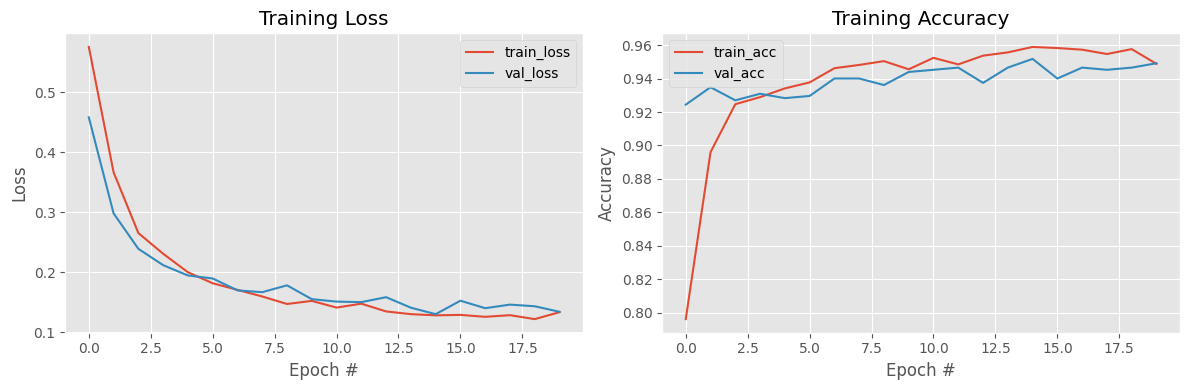

In [135]:
N = EPOCHS
plt.style.use("ggplot")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(np.arange(0, N), history["loss"], label="train_loss")
plt.plot(np.arange(0, N), history["val_loss"], label="val_loss")
plt.title("Training Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.arange(0, N), history["accuracy"], label="train_acc")
plt.plot(np.arange(0, N), history["val_accuracy"], label="val_acc")
plt.title("Training Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()